In [22]:
import sys
import os

import anndata
import matplotlib.pyplot as plt
import mplscience
import networkx as nx
import numpy as np
import scanpy as sc
import seaborn as sns
import squidpy as sq
import pickle as pic
import pandas as pd

SPATIAL_PACKAGE="/path/to/spatial/package'"
DATA_DIR="/path/to/kpspatial/data/"
sys.path.append(SPATIAL_PACKAGE)

from utilities import colors



In [3]:
cell_type_colors = colors.SLIDETAGS_COLORS

# hotspot_clusters = pd.read_csv(f"{DATA_DIR}/slideseq/expression/hotspot_modules_consensus.tsv", sep='\t', index_col=0)
zone_talk_markers_genes = pd.read_csv('./data/LARIS_output_to_Matt_marker_interactions_May8th2025_KP_tracer_Slidetags.csv', sep=',', index_col=0)
zone_talk_interactions = pd.read_csv('./data/LARIS_output_to_Matt_expanding_nonexpanding_May8th2025_KP_tracer_Slidetags.csv', sep=',', index_col = 0)

lr_adata = sc.read_h5ad(f"{DATA_DIR}/slidetags/expression/lr_adata_expanding_filtered_expand_nonexpand_LARIS_KP_Slidetags.h5ad")

tumor_states = ['AT1-like',
              'AT2-like',
              'Early EMT',
              'Early gastric',
              'Endoderm-like',
              'Gastric-like',
              'High-plasticity cell state',
              'Late gastric',
              'Neuronal-like',
              'Pre-EMT']

# hotspot_clusters.head(5)

In [4]:
plt.rcParams['figure.figsize'] = 4, 4
from matplotlib import cm
from matplotlib import colors, colorbar
cmap_own = cm.get_cmap('magma_r', 256)
newcolors = cmap_own(np.linspace(0,0.75 , 256))
Greys = cm.get_cmap('Greys_r', 256)
newcolors[:10, :] = Greys(np.linspace(0.8125, 0.8725, 10))
pos_cmap = colors.ListedColormap(newcolors)

x_width=lr_adata.obsm['X_spatial_split'][:,0].max()-lr_adata.obsm['X_spatial_split'][:,0].min()
y_width=lr_adata.obsm['X_spatial_split'][:,1].max()-lr_adata.obsm['X_spatial_split'][:,1].min()

plt.rcParams['figure.figsize'] = 10, 10*y_width/x_width

/tmp/ipykernel_508504/1656216162.py:4: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_own = cm.get_cmap('magma_r', 256)
/tmp/ipykernel_508504/1656216162.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  Greys = cm.get_cmap('Greys_r', 256)


In [18]:
# Example to query the interations

receiving = 'cancer_expanding'
sending = 'MonoMac_expanding'
zone_talk_interactions.loc[(zone_talk_interactions['sending_celltype'] == receiving) & 
                      (zone_talk_interactions['receiving_celltype'] == sending),
    ['interaction_name', 'interaction_score']].sort_values(by='interaction_score', ascending=False).head(7)

,interaction_name,interaction_score
59,Spp1::Itga4,0.117179
148,Fn1::Itga4,0.049039
261,Spp1::Itgb5,0.028688
2545,Il34::Csf1r,0.001183
3805,Mif::Cd74,0.000530
5672,Angptl2::Pirb,0.000207
6019,Wnt7b::Lrp6,0.000179


In [11]:
def plot_top_interactions(sender_groups, receiver_groups, interactions, section = 'both', top=5, plot_title=None, plot_rows='senders'):

    # reds_cmap = plt.get_cmap('Reds')
    # blend_string = "blend:#FFFFFF," + ",".join([matplotlib.colors.rgb2hex(reds_cmap(i)) for i in range(cmap.N)])    
    
    hits_to_combine = []
    x_order = []
    for sender in sender_groups:

        for receiver in receiver_groups:
        
            hits = interactions.loc[(interactions['sending_celltype'] == f'{sender}_expanding') & 
                                  (interactions['receiving_celltype'] == f'{receiver}_expanding'),
                                                            ['interaction_name', 'interaction_score']].sort_values(by='interaction_score', ascending=False).head(top)
            hits['sender'] = f'{sender}_expanding'
            hits['receiver'] = f'{receiver}_expanding'
            hits['interaction_score'] = -np.log10(hits['interaction_score'])
            hits['rank'] = hits['interaction_score'].rank(ascending=False)
            hits['compartment'] = 'expanding'
            _order = list(np.setdiff1d(hits.sort_values(by='interaction_score', ascending=False)['interaction_name'].values, x_order))
            x_order += _order
            hits_to_combine.append(hits)

    for sender in sender_groups:

        for receiver in receiver_groups:
            hits = interactions.loc[(interactions['sending_celltype'] == f'{sender}_non_expanding') & 
                                  (interactions['receiving_celltype'] == f'{receiver}_non_expanding'),
                                                            ['interaction_name', 'interaction_score']].sort_values(by='interaction_score', ascending=False).head(top)
            hits['sender'] = f'{sender}_non_expanding'
            hits['receiver'] = f'{receiver}_non_expanding'
            hits['rank'] = hits['interaction_score'].rank(ascending=False)
            hits['compartment'] = 'non-expanding'
            _order = list(np.setdiff1d(hits.sort_values(by='interaction_score', ascending=False)['interaction_name'].values, x_order))
            x_order += _order
            hits['interaction_score'] = -np.log10(hits['interaction_score'])
            hits_to_combine.append(hits)
        

    all_hits = pd.concat(hits_to_combine)

    with mplscience.style_context():        

        if plot_rows == 'senders':
            
            hits_piv = pd.pivot(all_hits, columns='interaction_name', index = 'sender', values='interaction_score')
            hits_piv.fillna(0, inplace=True)
            cell_type_order = [f'{sender}_expanding' for sender in sender_groups]
            cell_type_order += [f'{sender}_non_expanding' for sender in sender_groups]
            
            h = plt.figure(figsize=(25, 5))
            sns.heatmap(hits_piv.loc[cell_type_order,x_order], cmap='Reds', vmax=3)
            plt.gca().set_xticks(range(len(x_order)))
            plt.gca().set_xticklabels(x_order)
            plt.xlabel("Interaction")
            plt.ylabel("Compartment")
            plt.title(f"Interactions x->{receiver_groups[0]}")
            if plot_title:
                plt.savefig(f"./figures/{plot_title}", bbox_inches='tight')
            plt.show()

        else:
            
            hits_piv = pd.pivot(all_hits, columns='interaction_name', index = 'receiver', values='interaction_score')
            hits_piv.fillna(0, inplace=True)
            cell_type_order = [f'{receiver}_expanding' for receiver in receiver_groups]
            cell_type_order += [f'{receiver}_non_expanding' for receiver in receiver_groups]
            
            h = plt.figure(figsize=(25, 5))
            sns.heatmap(hits_piv.loc[cell_type_order,x_order], cmap='Reds', vmax=3)
            plt.xlabel("Interaction")
            plt.ylabel("Compartment")
            plt.title(f"Interactions {sender_groups[0]} -> x")
            if plot_title:
                plt.savefig(f"./figures/{plot_title}", bbox_inches='tight')
            plt.show()
            
        
    return all_hits
    

def plot_interactions_plot(_from_groups, focus_groups, interactions, section = 'both', top=5, plot_title=None):

    from_groups = []
    for g in _from_groups:

        if section == 'expanding' or section == 'both':
            from_groups.append(f'{g}_expanding')
            
    for g in _from_groups:
        if section == 'non_expanding' or section == 'both':
            from_groups.append(f'{g}_non_expanding')

    marker_genes_list = {}
    all_names = []
    for group in focus_groups:
    
        for group2 in _from_groups:

            if section == 'expanding' or section == 'both':
                _lst = list(interactions.loc[(interactions['sending_celltype'] == f'{group2}_expanding') & 
                              (interactions['receiving_celltype'] == f'{group}_expanding'),
                                                        ['interaction_name', 'interaction_score']].sort_values(by='interaction_score', ascending=False).head(top)['interaction_name'].values)
                
                if len(np.setdiff1d(_lst, all_names)) > 0:
                    marker_genes_list[f'{group}_expanding'] = np.setdiff1d(_lst, all_names)

                # all_names += list(np.setdiff1d(_lst, all_names))

            if section == 'non_expanding' or section == 'both': 
        
                
                _lst = list(interactions.loc[(interactions['sending_celltype'] == f'{group2}_non_expanding') & 
                              (interactions['receiving_celltype'] == f'{group}_non_expanding'),
                                                        ['interaction_name', 'interaction_score']].sort_values(by='interaction_score', ascending=False).head(top)['interaction_name'].values)
                if len(np.setdiff1d(_lst, all_names)) > 0:
                    marker_genes_list[f'{group}_non_expanding'] = np.setdiff1d(_lst, all_names)
            

    with mplscience.style_context():
        sc.pl.matrixplot(lr_adata[lr_adata.obs['immune_stromal_expand_non_expand_status'].isin(from_groups),:], marker_genes_list,
                     groupby='immune_stromal_expand_non_expand_status',
                     dendrogram=False,
                     swap_axes=False,
                     vmax=7,
                     cmap='Reds',
                     categories_order = from_groups,
                     show=False
                     )
        # if plot_title:
        #     plt.savefig(f"./figures/{plot_title}", bbox_inches='tight')
        plt.show()

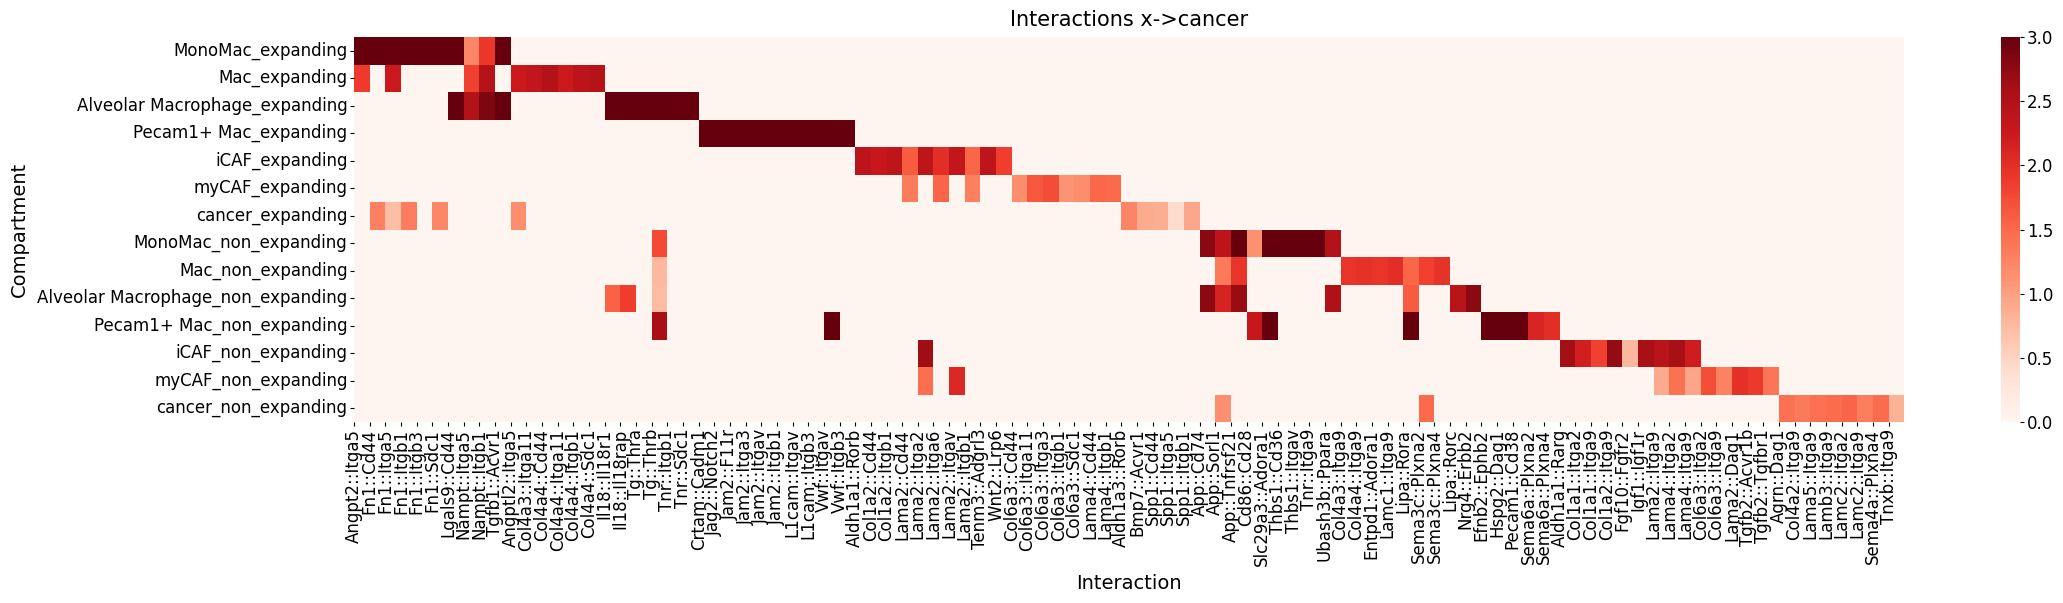

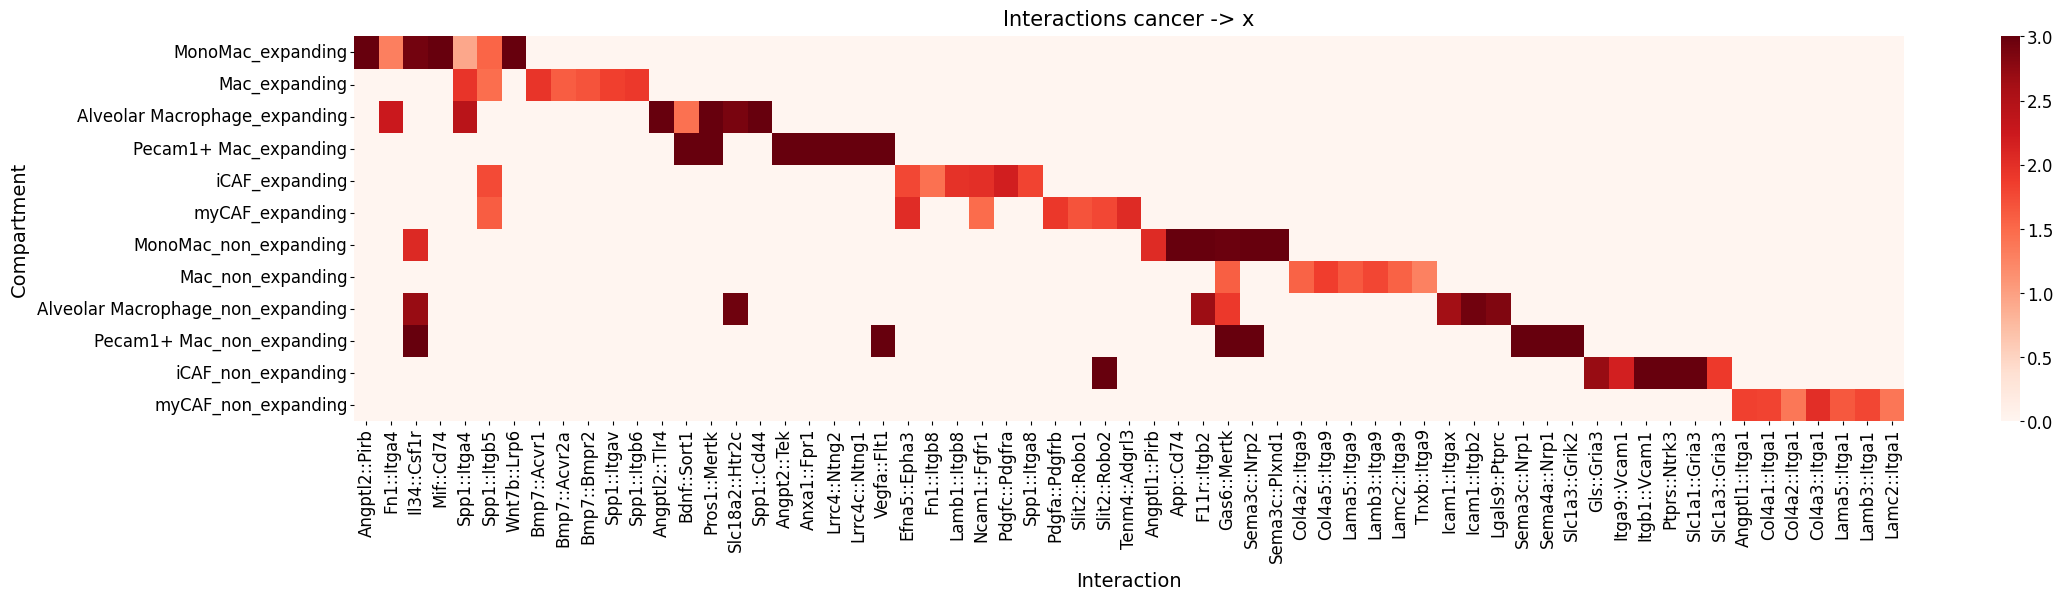

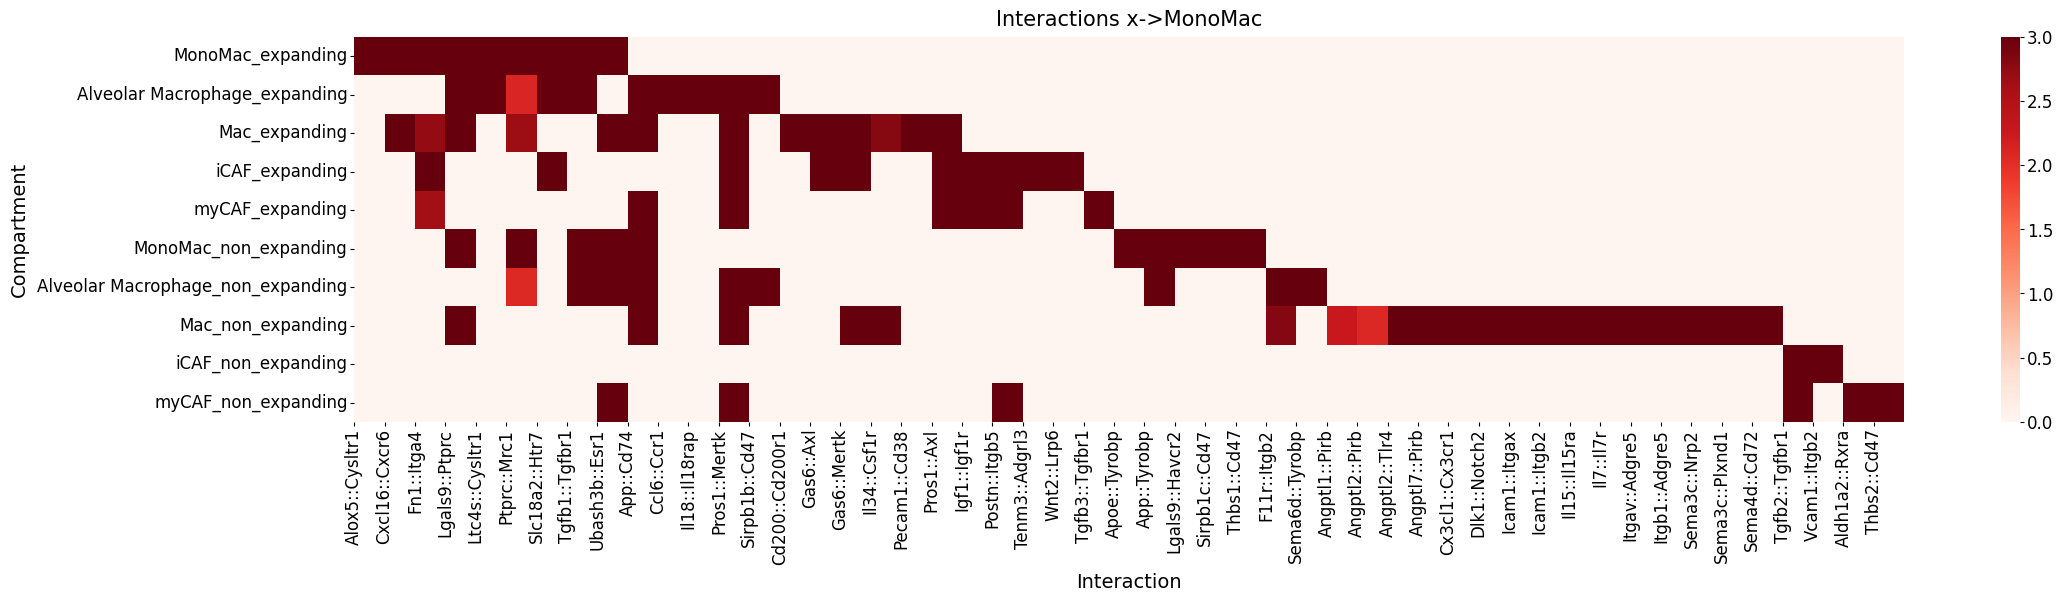

In [14]:
sender_groups = ['MonoMac', 'Mac', 'Alveolar Macrophage', 'Pecam1+ Mac', 'iCAF', 'myCAF', 'cancer']
focus_group = ['cancer']
all_hits = plot_top_interactions(sender_groups, focus_group, zone_talk_interactions, section='both', top=10, plot_title=None)

sender_groups = ['cancer']
focus_group = ['MonoMac', 'Mac', 'Alveolar Macrophage', 'Pecam1+ Mac', 'iCAF', 'myCAF']
all_hits = plot_top_interactions(sender_groups, focus_group, zone_talk_interactions, section='both', top=7, plot_title=None, plot_rows='receivers')

sender_groups = ['MonoMac', 'Alveolar Macrophage', 'Mac', 'iCAF', 'myCAF']
focus_group = ['MonoMac']
all_hits = plot_top_interactions(sender_groups, focus_group, zone_talk_interactions, section='both', top=30, plot_title=None, plot_rows='senders')

/tmp/ipykernel_508504/62257838.py:2: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(


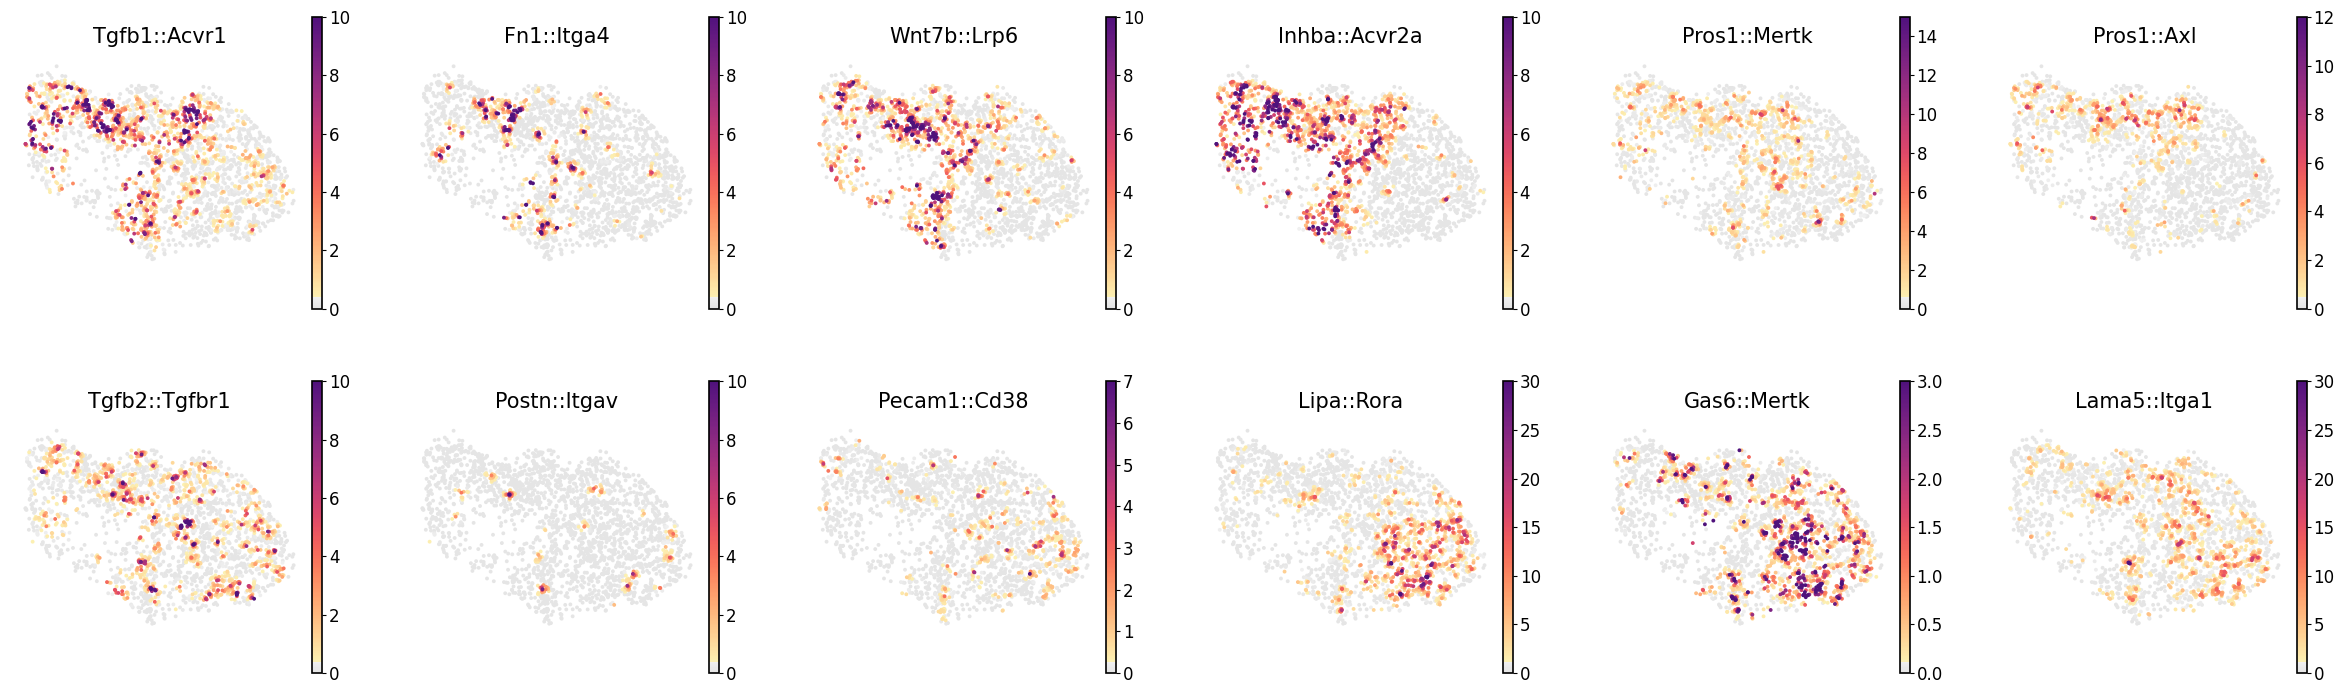

/tmp/ipykernel_508504/62257838.py:12: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(


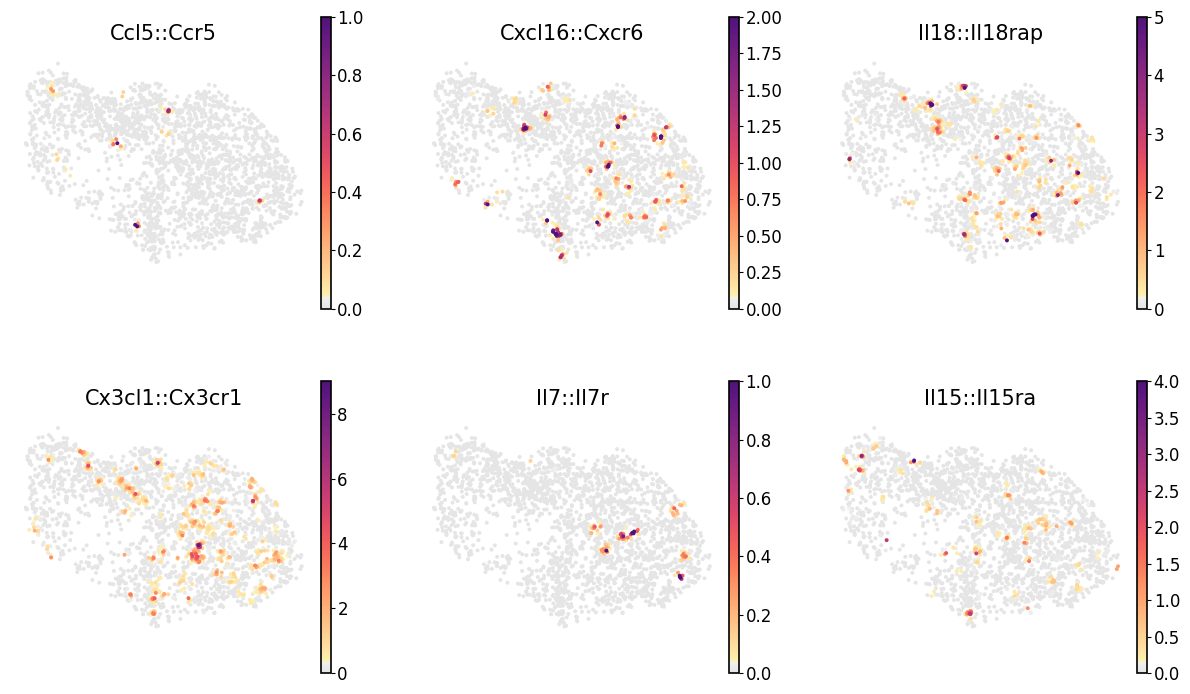

In [20]:
with mplscience.style_context():
    sc.pl.spatial(
        lr_adata[lr_adata.obs['batch'] == 'Layer3_Puck1',:],
        color = ['Tgfb1::Acvr1', 'Fn1::Itga4', 'Wnt7b::Lrp6', 'Inhba::Acvr2a', 'Pros1::Mertk', 'Pros1::Axl',
                 'Tgfb2::Tgfbr1', 'Postn::Itgav', 'Pecam1::Cd38', 'Lipa::Rora', 'Gas6::Mertk', 'Lama5::Itga1'],
        cmap=pos_cmap,
        vmax=[10, 10, 10, 10, 15, 12, 10, 10, 7, 30, 3, 30], ncols=6,
        spot_size=60, frameon=False, show=False)
    plt.show()

with mplscience.style_context():
    sc.pl.spatial(
        lr_adata[lr_adata.obs['batch'] == 'Layer3_Puck1',:],
        color = ['Ccl5::Ccr5', 'Cxcl16::Cxcr6', 'Il18::Il18rap', 'Cx3cl1::Cx3cr1', 'Il7::Il7r', 'Il15::Il15ra'],
        cmap=pos_cmap,
        vmax=[1, 2, 5, 9, 1, 4], ncols=3,
        spot_size=60, frameon=False, show=False)
    plt.show()

/tmp/ipykernel_508504/2511858451.py:2: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(


ERROR: The parameter vmax is not valid. If setting multiple vmax values,check that the length of the vmax list is equal to the number of plots. 


/orcd/data/ki/001/lab/jones/mgjones/miniconda3/envs/spatial-tracer/lib/python3.11/site-packages/scanpy/plotting/_utils.py:465: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[f"{value_to_plot}_colors"] = colors_list


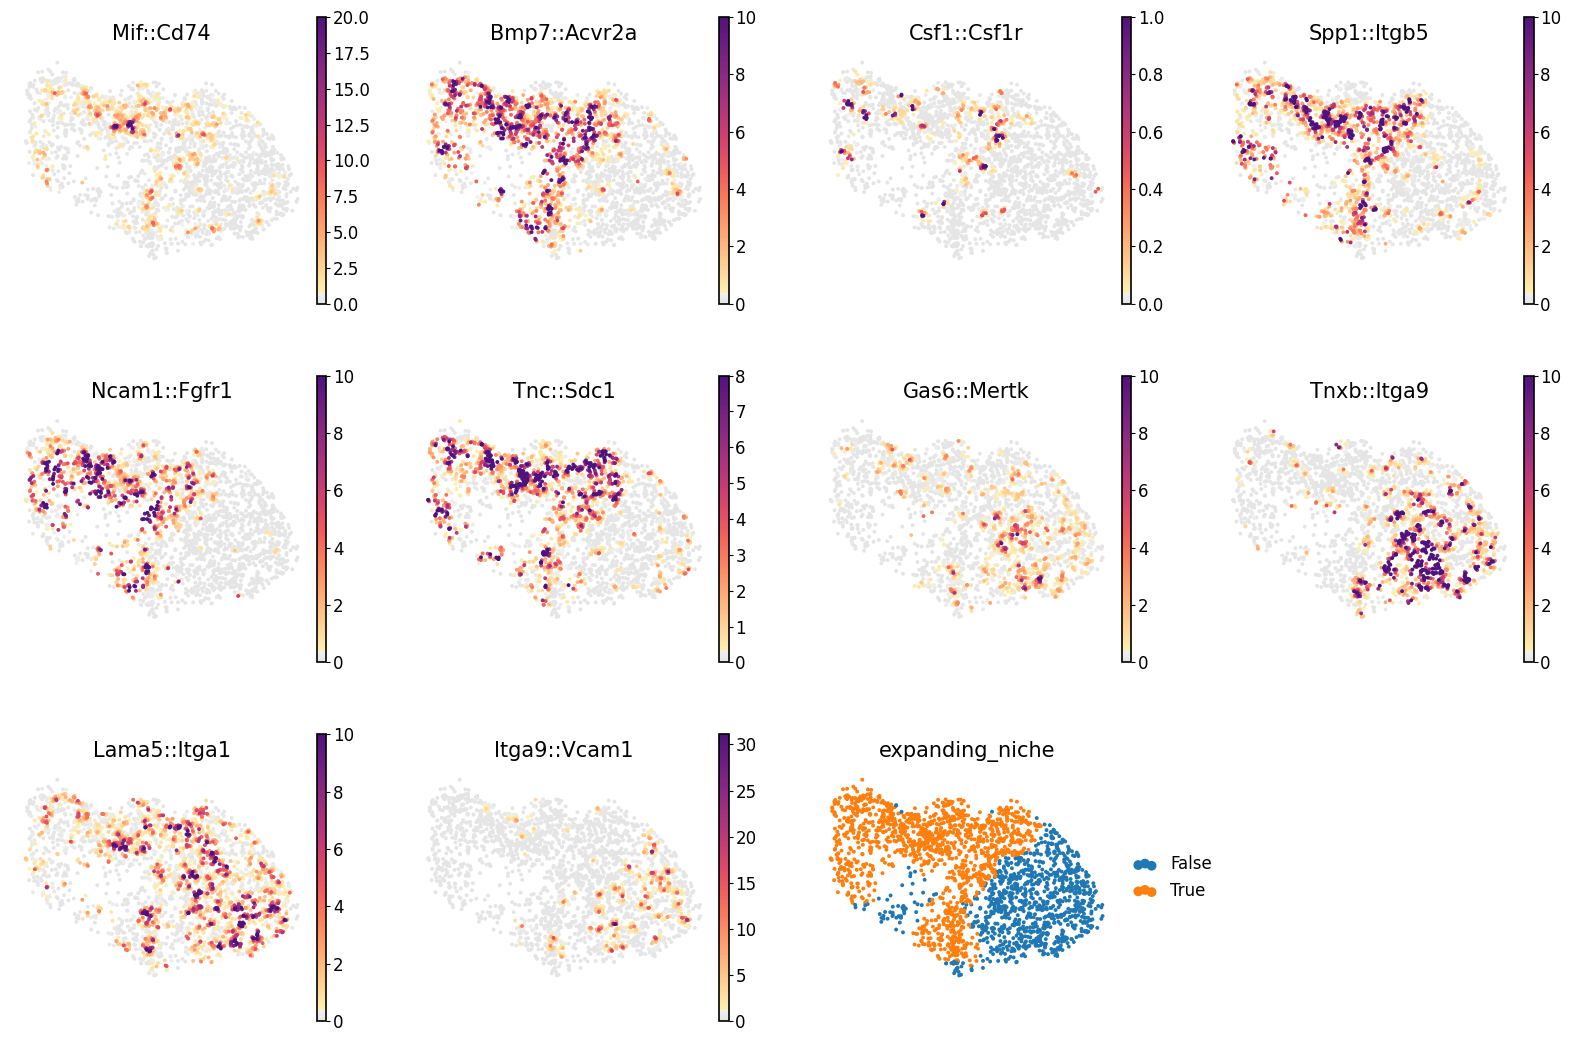

In [21]:
with mplscience.style_context():
    sc.pl.spatial(
        lr_adata[lr_adata.obs['batch'] == 'Layer3_Puck1',:],
        color=['Mif::Cd74', 'Bmp7::Acvr2a', 'Csf1::Csf1r', 'Spp1::Itgb5', 'Ncam1::Fgfr1', 'Tnc::Sdc1',
               'Gas6::Mertk', 'Tnxb::Itga9', 'Lama5::Itga1', 'Itga9::Vcam1', 'expanding_niche'],
        cmap=pos_cmap,
        vmax=[20, 10, 1, 10, 10, 8, 10, 10, 10],
        spot_size=60, frameon=False, show=False)
    plt.show()